In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [8]:
df = pd.read_csv("train.csv")
df

,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,5894,5895,28,Other,4.56,7.61,1.70,7.23,3.80,3.18,2,256,102,14,52.72,6,68,70.48,55.29
1,3728,3729,18,Female,7.95,8.17,4.24,5.50,4.80,3.53,9,370,115,17,87.51,1,69,57.67,78.68
2,8958,8959,19,Male,6.06,9.02,3.17,5.08,5.09,3.74,5,250,33,9,72.39,8,57,72.51,60.66
3,7671,7672,21,Female,1.40,8.06,2.35,1.03,0.13,5.23,4,55,110,0,87.47,5,34,81.93,37.51
4,5999,6000,25,Male,9.27,7.39,10.68,5.21,3.43,5.38,11,436,66,17,47.66,5,37,49.11,50.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,11284,11285,18,Female,1.04,4.86,6.58,2.73,0.35,1.57,10,462,63,2,62.40,1,80,80.24,35.63
15996,11964,11965,29,Male,4.85,8.61,4.66,5.79,1.98,5.08,9,317,47,3,40.52,10,43,57.97,40.07
15997,5390,5391,25,Other,7.97,8.72,11.30,2.54,3.67,3.57,13,290,105,7,75.09,5,71,40.71,63.14
15998,860,861,21,Female,2.64,8.64,1.47,5.01,5.24,3.18,3,62,116,18,73.99,6,31,76.56,41.62


In [9]:
df.isnull().sum()

id                       0
student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64

In [10]:
df.shape

(16000, 19)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     16000 non-null  int64  
 1   student_id             16000 non-null  int64  
 2   age                    16000 non-null  int64  
 3   gender                 16000 non-null  str    
 4   study_hours_per_day    16000 non-null  float64
 5   sleep_hours            16000 non-null  float64
 6   phone_usage_hours      16000 non-null  float64
 7   social_media_hours     16000 non-null  float64
 8   youtube_hours          16000 non-null  float64
 9   gaming_hours           16000 non-null  float64
 10  breaks_per_day         16000 non-null  int64  
 11  coffee_intake_mg       16000 non-null  int64  
 12  exercise_minutes       16000 non-null  int64  
 13  assignments_completed  16000 non-null  int64  
 14  attendance_percentage  16000 non-null  float64
 15  stress_level 

In [14]:
df.describe()

,id,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,10006.506875,10007.506875,23.020937,5.254446,6.515254,6.258693,3.995989,2.985526,2.976373,7.539625,249.035250,59.832125,9.492313,69.894694,5.478813,64.430375,70.377071,50.146637
std,5790.786923,5790.786923,3.753283,2.743874,2.033761,3.305756,2.311722,1.731141,1.733127,4.017236,143.732208,34.676427,5.781352,17.408698,2.867785,20.226804,17.293340,16.095733
min,1.000000,2.000000,17.000000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,4993.750000,4994.750000,20.000000,2.890000,4.760000,3.390000,2.000000,1.480000,1.477500,4.000000,124.000000,30.000000,4.000000,54.740000,3.000000,47.000000,55.617500,38.657500
50%,10020.500000,10021.500000,23.000000,5.250000,6.520000,6.230000,3.990000,2.970000,2.950000,8.000000,248.000000,60.000000,9.000000,69.865000,5.000000,65.000000,70.545000,50.220000
75%,15029.250000,15030.250000,26.000000,7.632500,8.320000,9.100000,5.970000,4.480000,4.490000,11.000000,372.000000,90.000000,15.000000,85.020000,8.000000,82.000000,85.480000,61.840000
max,19999.000000,20000.000000,29.000000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [15]:
df.head(5)

,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,5894,5895,28,Other,4.56,7.61,1.70,7.23,3.80,3.18,2,256,102,14,52.72,6,68,70.48,55.29
1,3728,3729,18,Female,7.95,8.17,4.24,5.50,4.80,3.53,9,370,115,17,87.51,1,69,57.67,78.68
2,8958,8959,19,Male,6.06,9.02,3.17,5.08,5.09,3.74,5,250,33,9,72.39,8,57,72.51,60.66
3,7671,7672,21,Female,1.40,8.06,2.35,1.03,0.13,5.23,4,55,110,0,87.47,5,34,81.93,37.51
4,5999,6000,25,Male,9.27,7.39,10.68,5.21,3.43,5.38,11,436,66,17,47.66,5,37,49.11,50.72


In [16]:
df['gender'] = df['gender'].map({"Other": 0, "Female": 1, "Male": 2})

In [17]:
df.head(5)

,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,5894,5895,28,0,4.56,7.61,1.70,7.23,3.80,3.18,2,256,102,14,52.72,6,68,70.48,55.29
1,3728,3729,18,1,7.95,8.17,4.24,5.50,4.80,3.53,9,370,115,17,87.51,1,69,57.67,78.68
2,8958,8959,19,2,6.06,9.02,3.17,5.08,5.09,3.74,5,250,33,9,72.39,8,57,72.51,60.66
3,7671,7672,21,1,1.40,8.06,2.35,1.03,0.13,5.23,4,55,110,0,87.47,5,34,81.93,37.51
4,5999,6000,25,2,9.27,7.39,10.68,5.21,3.43,5.38,11,436,66,17,47.66,5,37,49.11,50.72


In [19]:
df.describe()

,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,10006.506875,10007.506875,23.020937,1.443188,5.254446,6.515254,6.258693,3.995989,2.985526,2.976373,7.539625,249.035250,59.832125,9.492313,69.894694,5.478813,64.430375,70.377071,50.146637
std,5790.786923,5790.786923,3.753283,0.568698,2.743874,2.033761,3.305756,2.311722,1.731141,1.733127,4.017236,143.732208,34.676427,5.781352,17.408698,2.867785,20.226804,17.293340,16.095733
min,1.000000,2.000000,17.000000,0.000000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,4993.750000,4994.750000,20.000000,1.000000,2.890000,4.760000,3.390000,2.000000,1.480000,1.477500,4.000000,124.000000,30.000000,4.000000,54.740000,3.000000,47.000000,55.617500,38.657500
50%,10020.500000,10021.500000,23.000000,1.000000,5.250000,6.520000,6.230000,3.990000,2.970000,2.950000,8.000000,248.000000,60.000000,9.000000,69.865000,5.000000,65.000000,70.545000,50.220000
75%,15029.250000,15030.250000,26.000000,2.000000,7.632500,8.320000,9.100000,5.970000,4.480000,4.490000,11.000000,372.000000,90.000000,15.000000,85.020000,8.000000,82.000000,85.480000,61.840000
max,19999.000000,20000.000000,29.000000,2.000000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


## Feature selecting Linear relationships

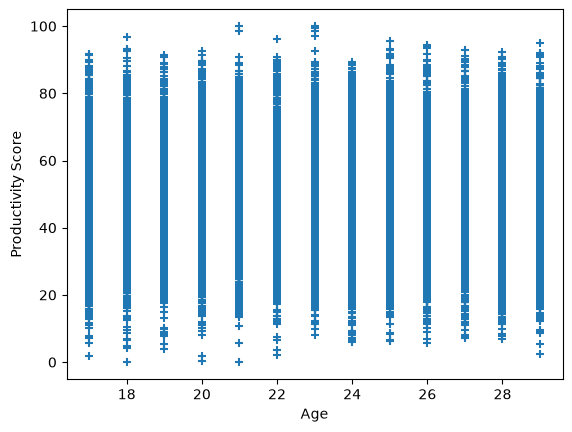

In [22]:
%matplotlib inline
plt.xlabel("Age")
plt.ylabel("Productivity Score")
plt.scatter(df.age, df.productivity_score, marker = "+")

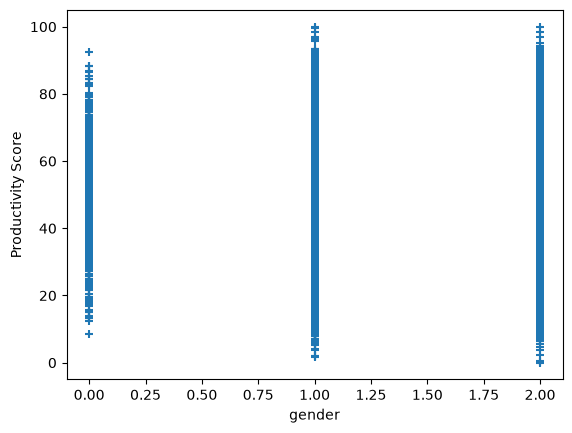

In [24]:
%matplotlib inline
plt.xlabel("gender")
plt.ylabel("Productivity Score")
plt.scatter(df.gender, df.productivity_score, marker = "+")

##Study hours per day (Linear Relationship)
obv : more hours studied a day = higher production score

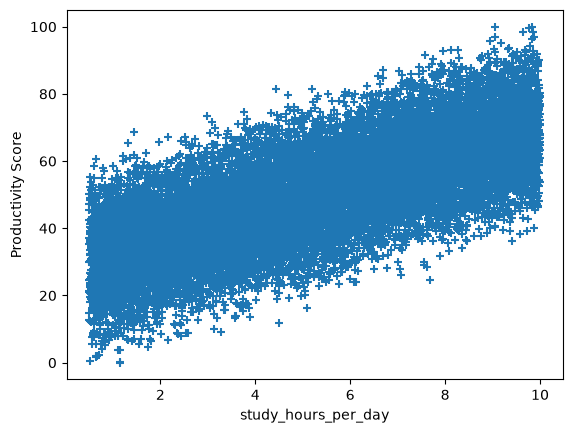

In [26]:
%matplotlib inline
plt.xlabel("study_hours_per_day")
plt.ylabel("Productivity Score")
plt.scatter(df.study_hours_per_day, df.productivity_score, marker = "+")

##Sleep hours (semi linear relationship)
Obv: more sleep = higher productiviy score

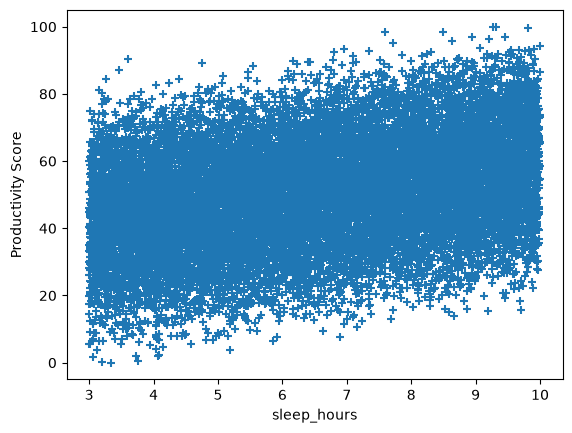

In [27]:
%matplotlib inline
plt.xlabel("sleep_hours")
plt.ylabel("Productivity Score")
plt.scatter(df.sleep_hours, df.productivity_score, marker = "+")

In [ ]:
##Phone usage (linear relationship)
Obv: less amount of house the more production hours

C:\Users\tkiya\anaconda3\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\tkiya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


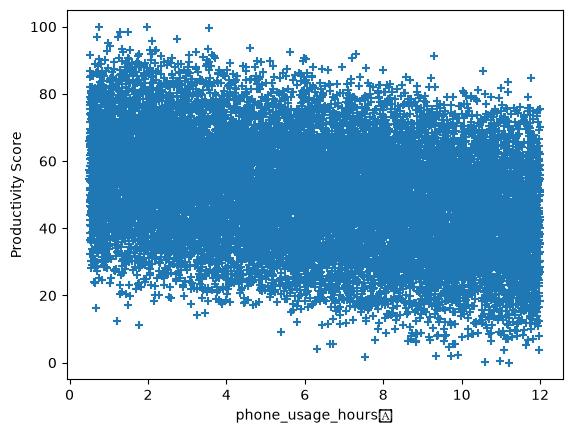

In [28]:
%matplotlib inline
plt.xlabel("phone_usage_hours	")
plt.ylabel("Productivity Score")
plt.scatter(df.phone_usage_hours	, df.productivity_score, marker = "+")

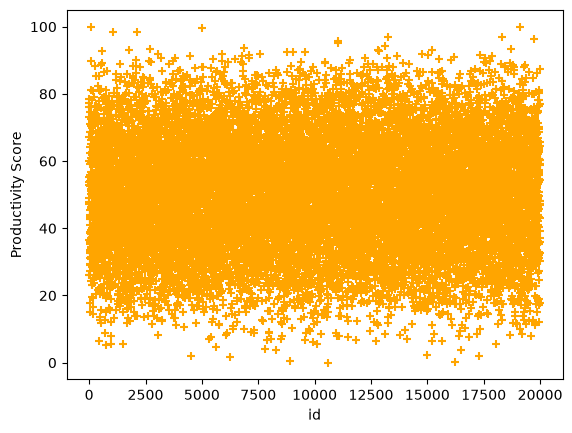

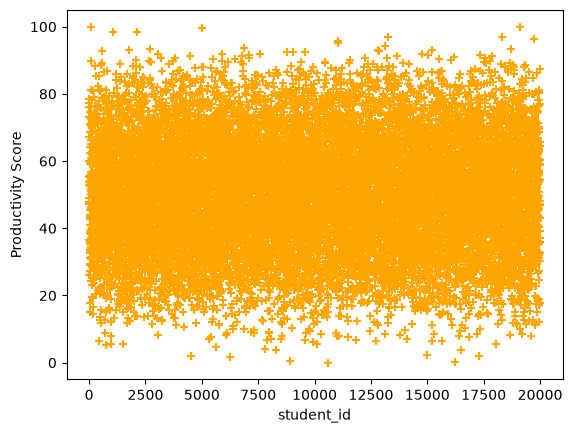

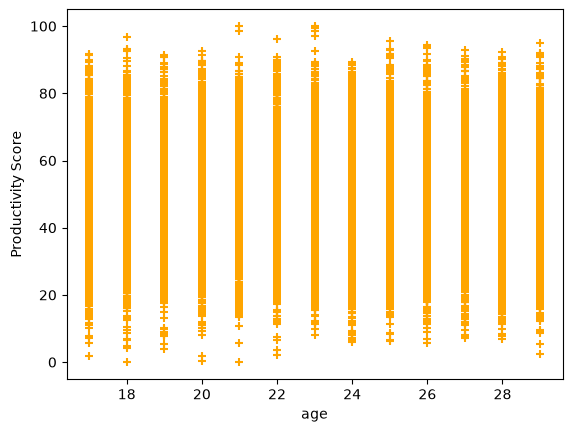

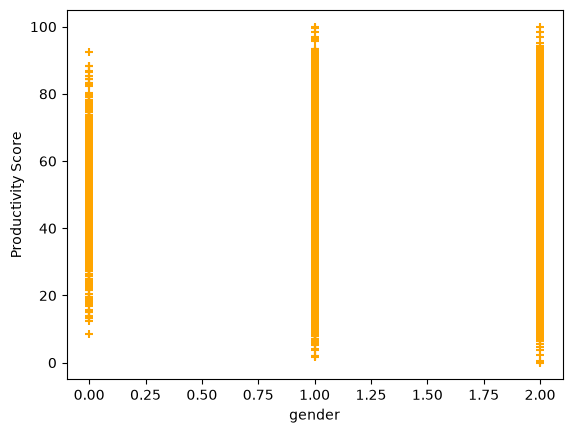

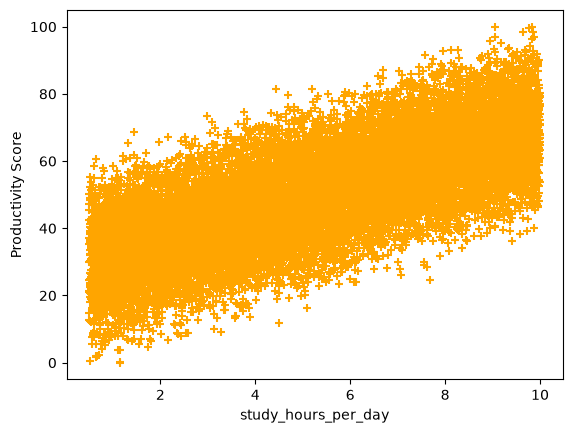

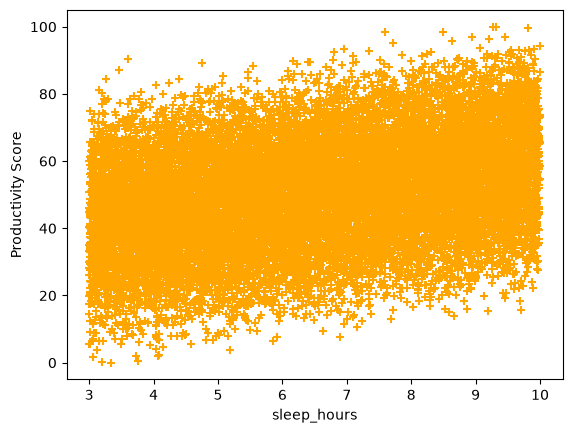

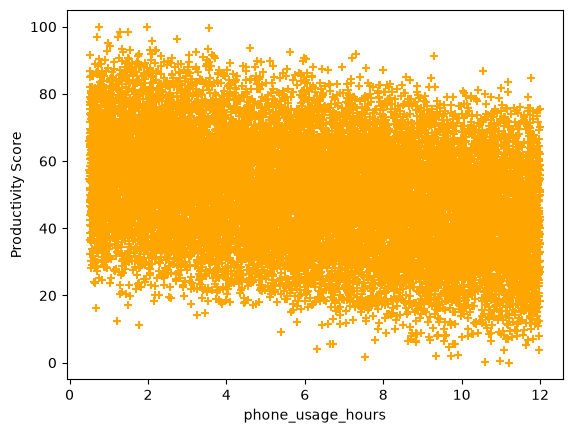

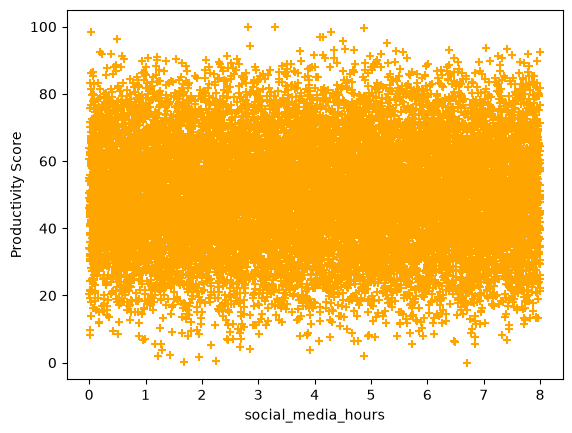

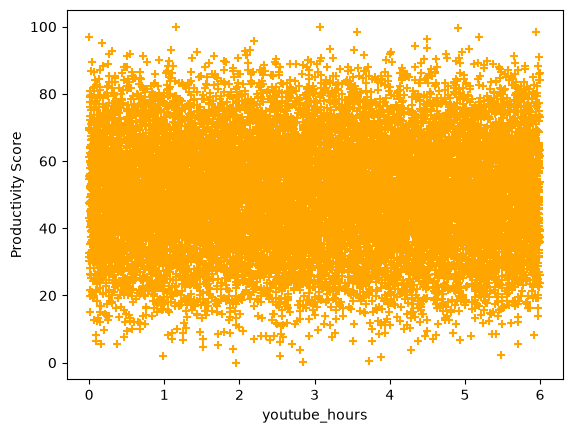

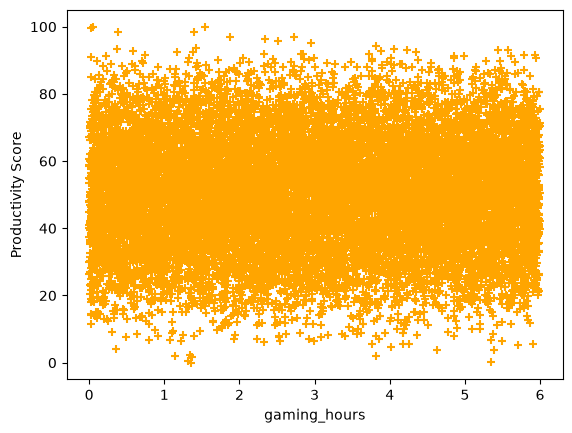

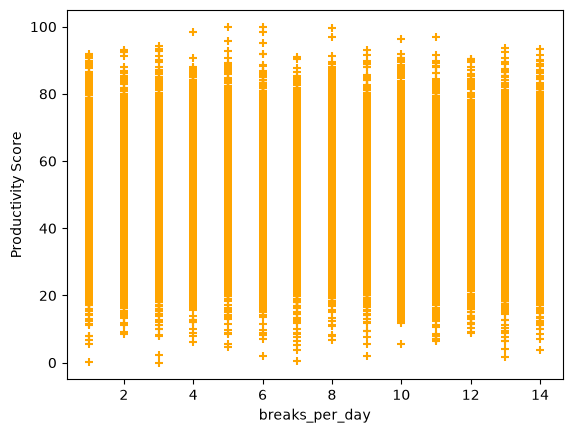

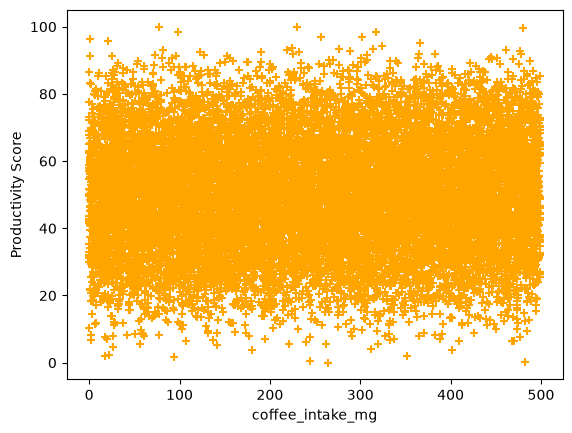

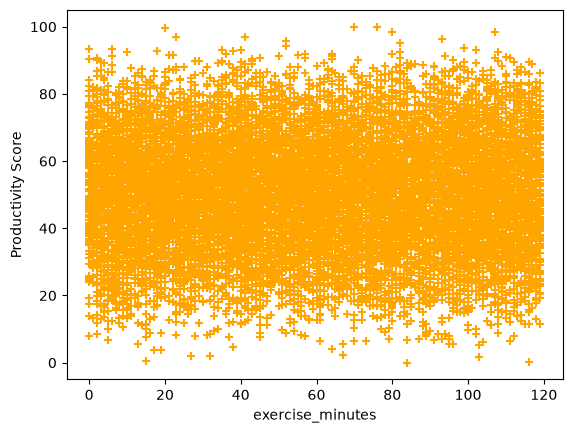

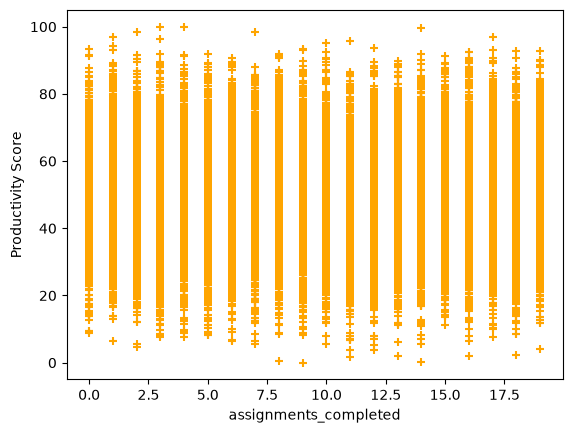

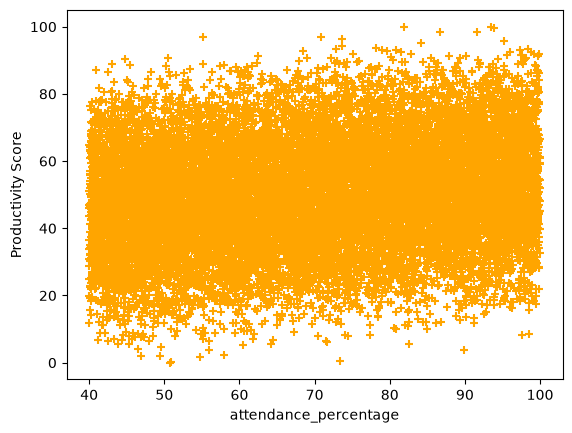

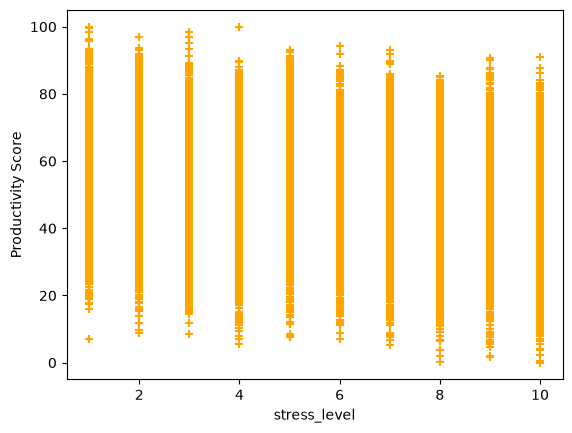

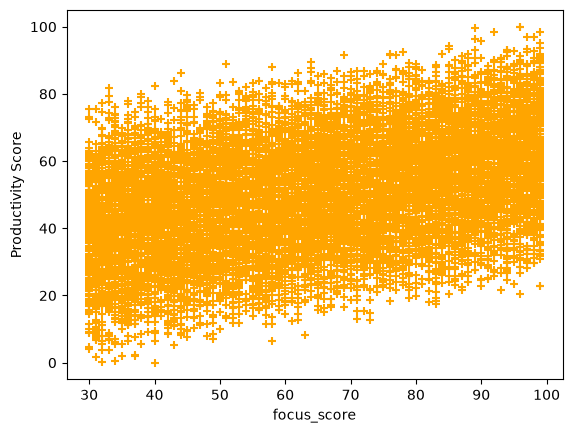

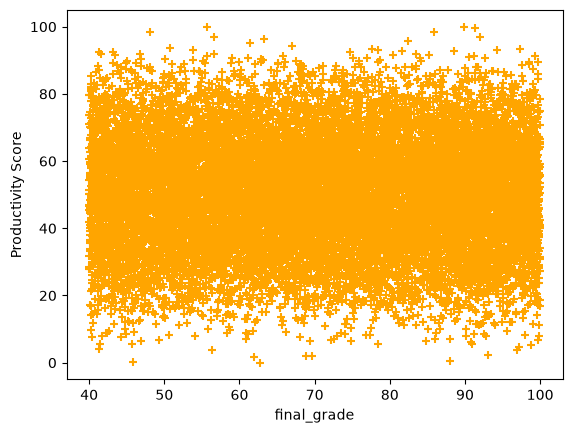

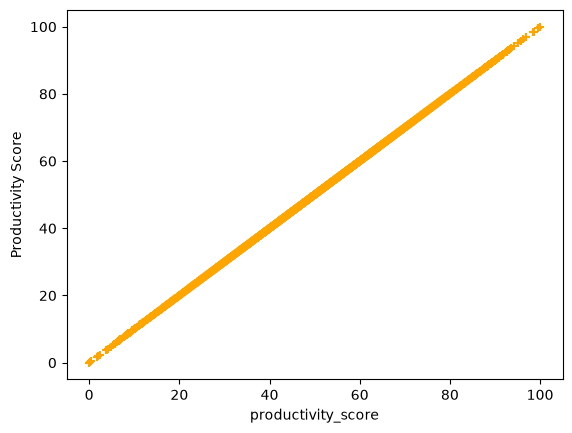

In [39]:
for i in df.columns:
    %matplotlib inline
    plt.xlabel(i)
    plt.ylabel("Productivity Score")
    plt.scatter(df[i]	, df.productivity_score, marker = "+", color = 'orange')
    plt.show()

## Testing Social media hours to see if it has a lienar relaitonshipw ith other features
ex. social media hours and sleep_hours maybe have a relaiton while sleep hours has a relaitonshiow with productivy hours

No lineear relationship with other feaures

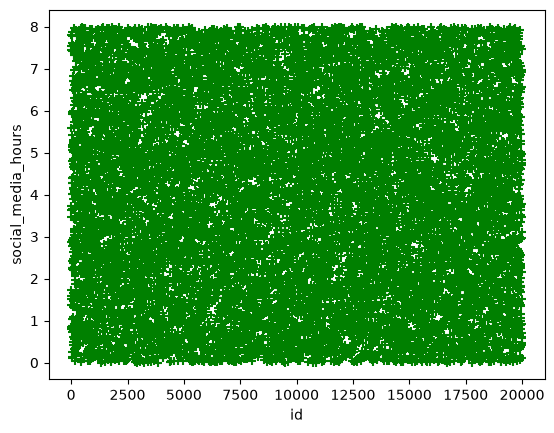

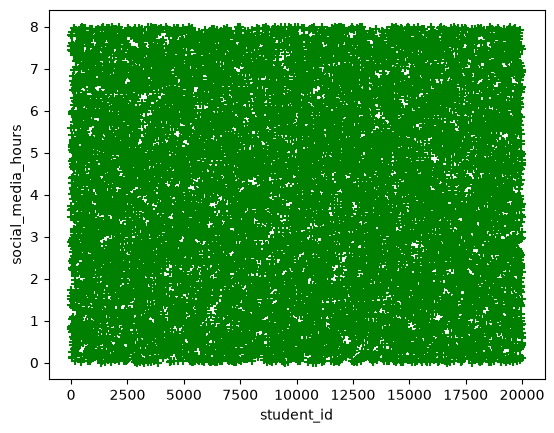

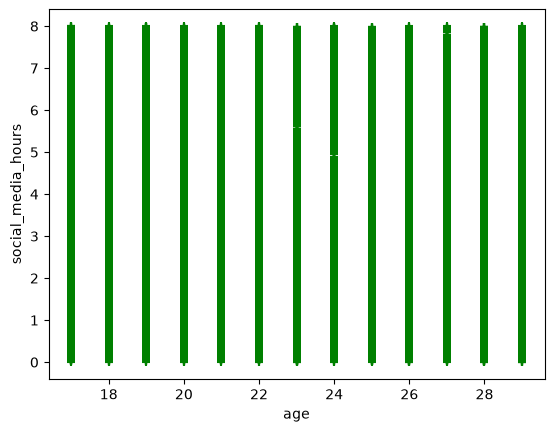

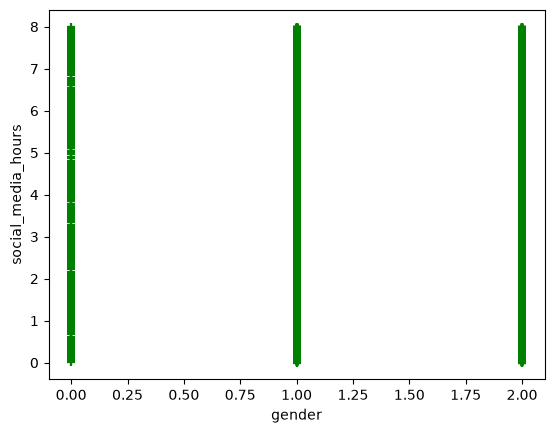

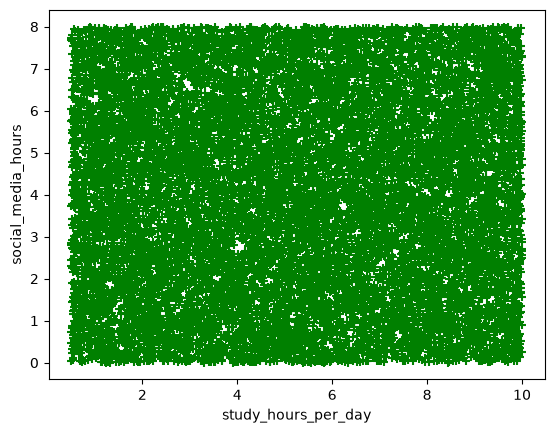

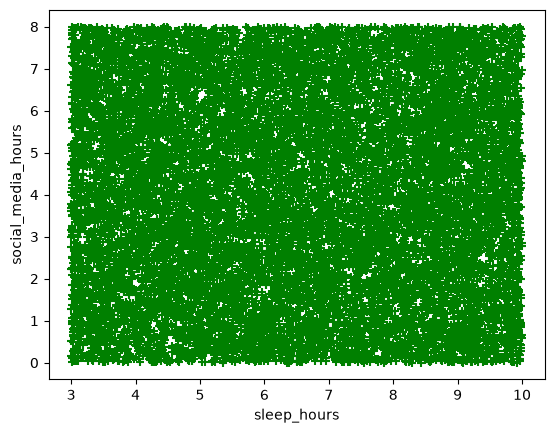

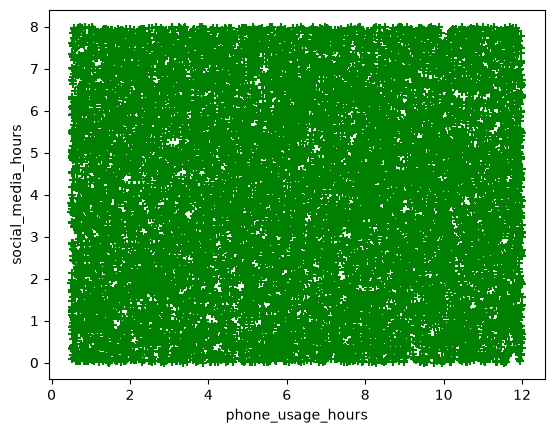

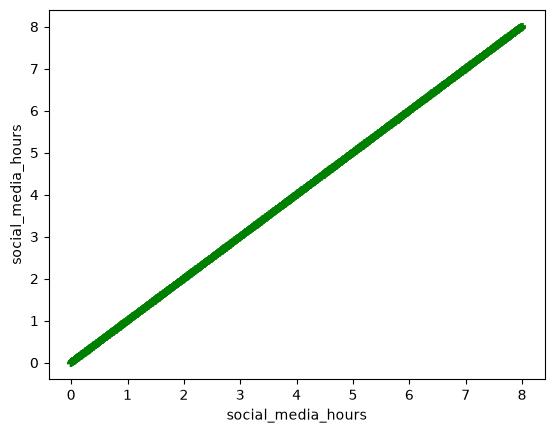

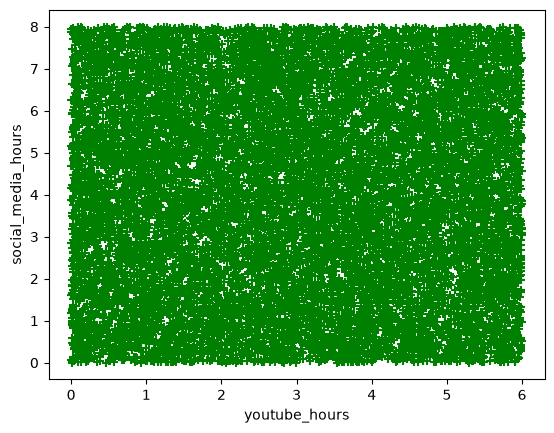

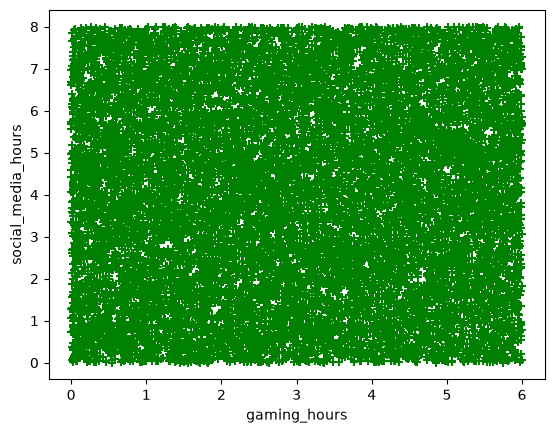

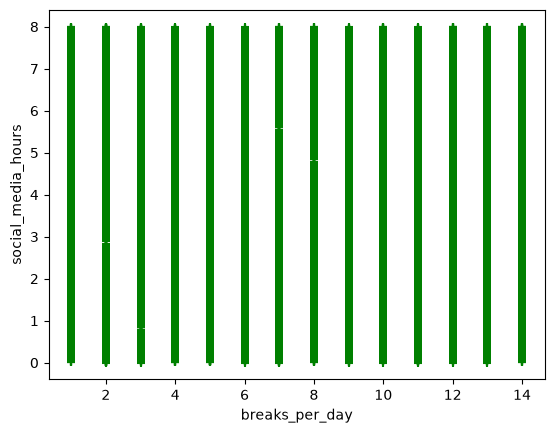

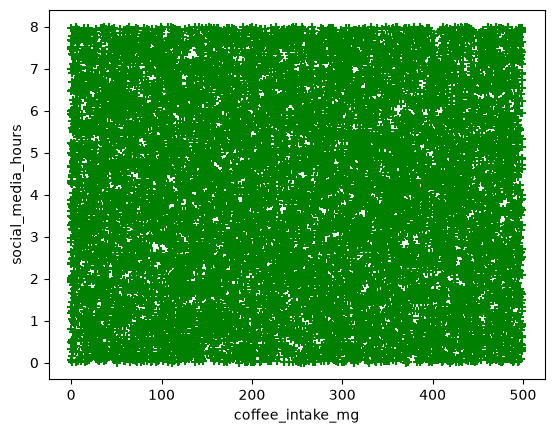

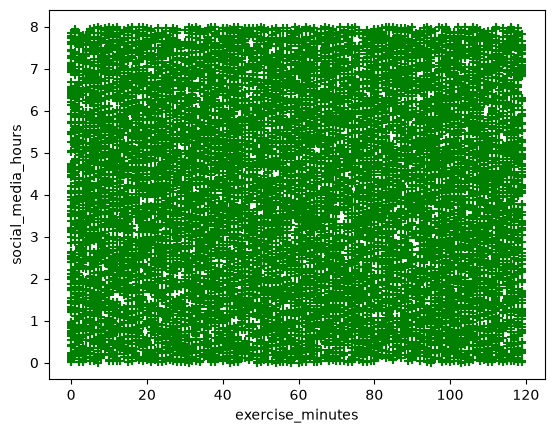

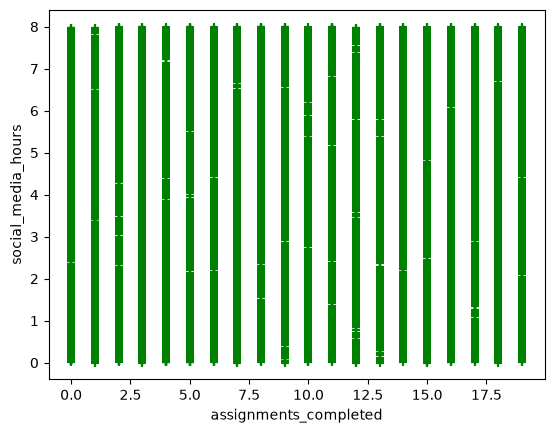

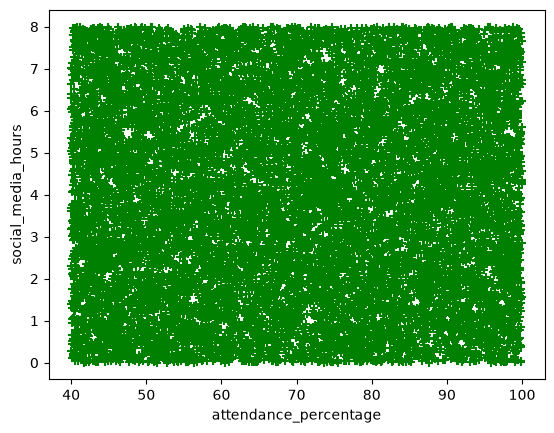

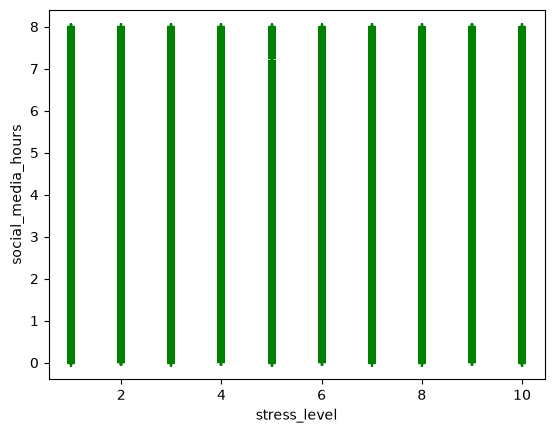

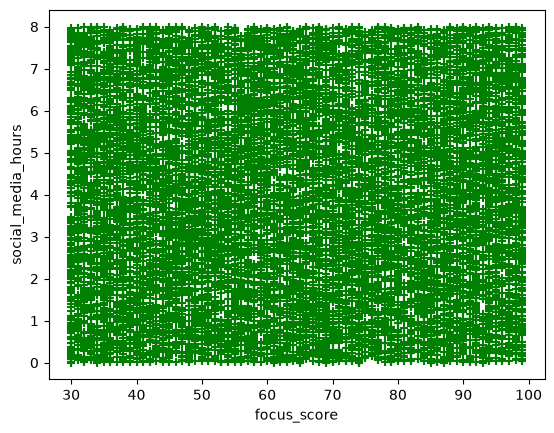

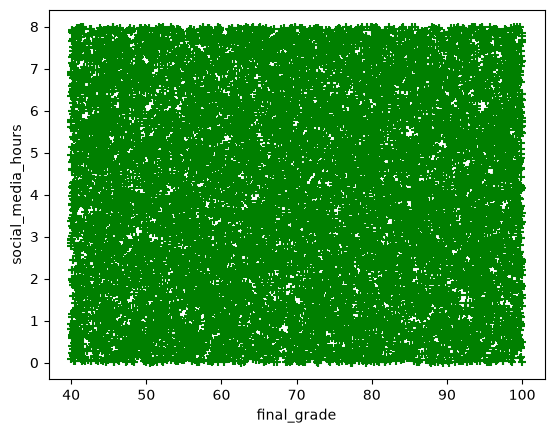

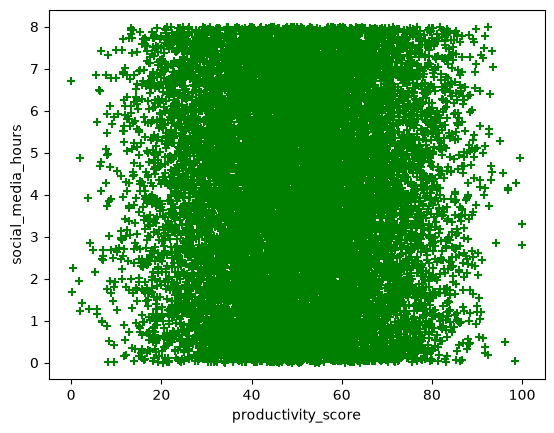

In [95]:
for i in df.columns:
    %matplotlib inline
    plt.xlabel(i)
    plt.ylabel("social_media_hours")
    plt.scatter(df[i]	, df.social_media_hours, marker = "+", color = 'green')
    plt.show()

## Testing youtube hours to see if it has a lienar relaitonshipw ith other features
No lineear relationship with other feaures

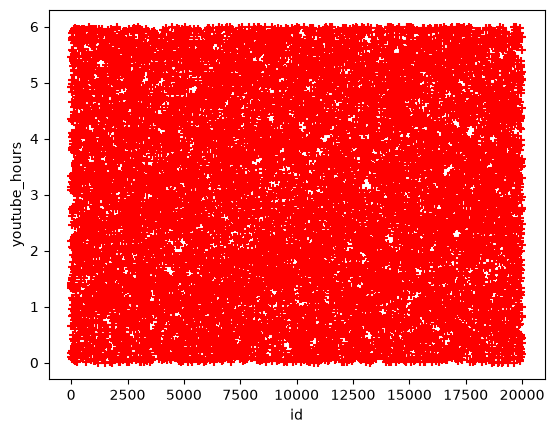

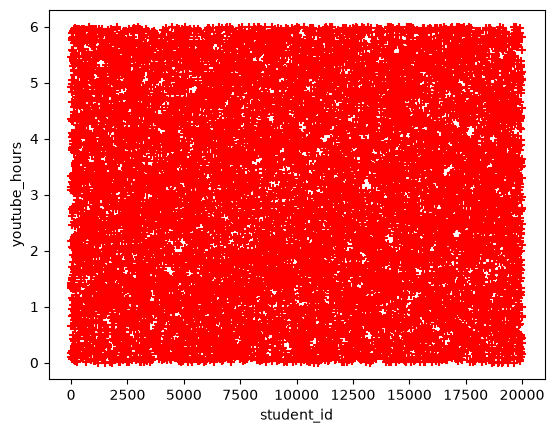

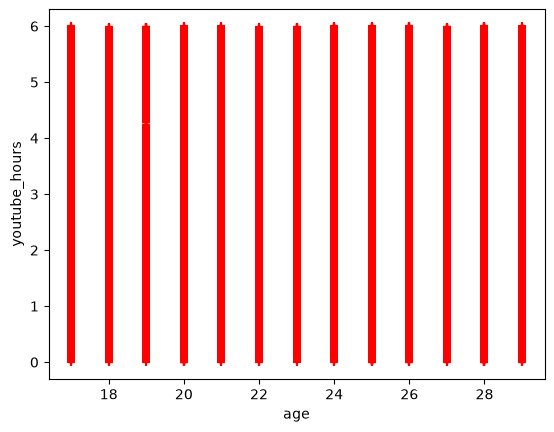

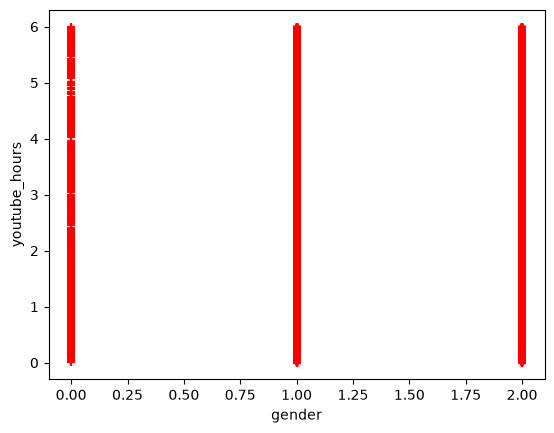

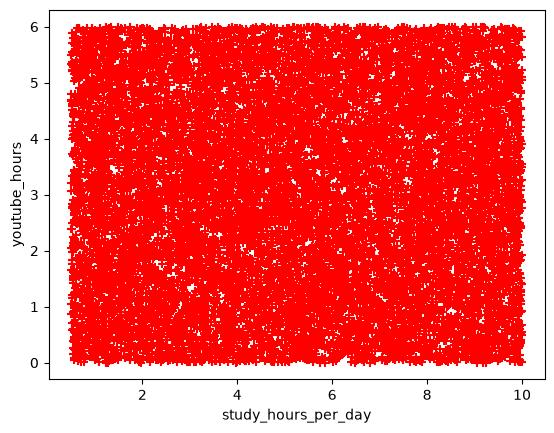

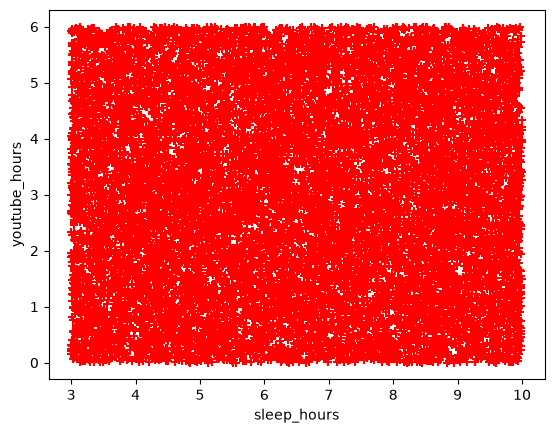

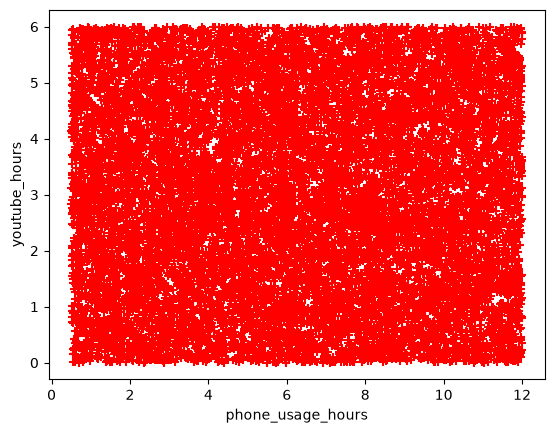

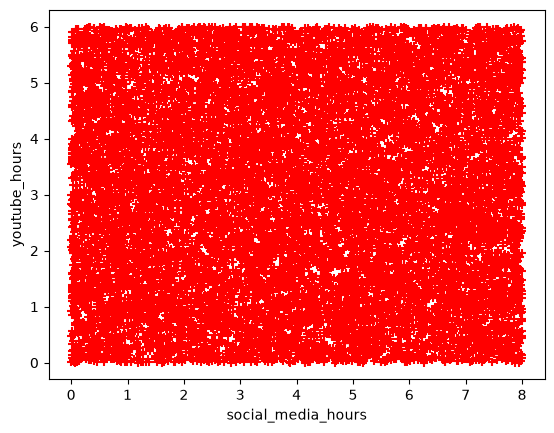

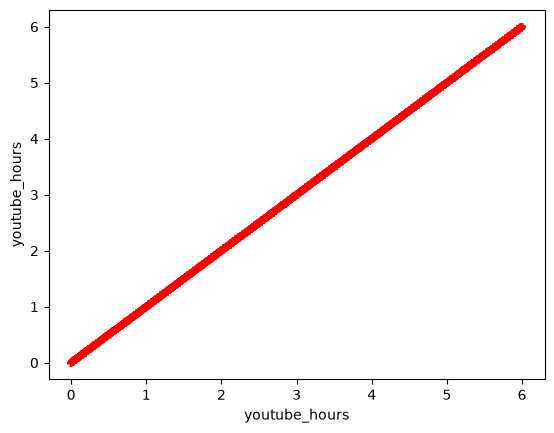

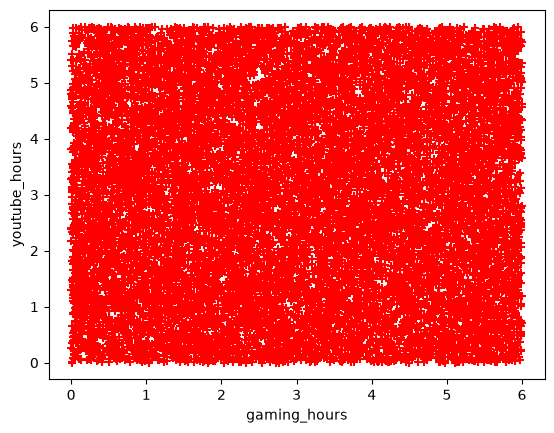

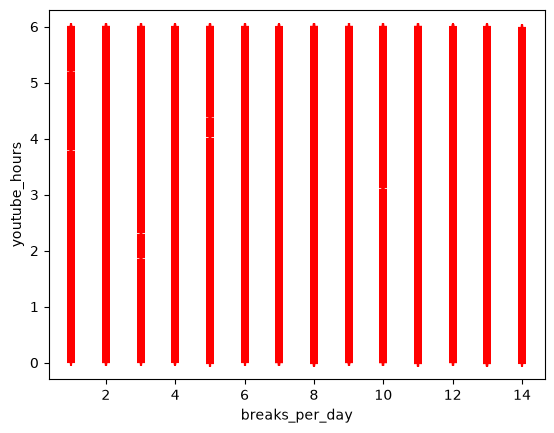

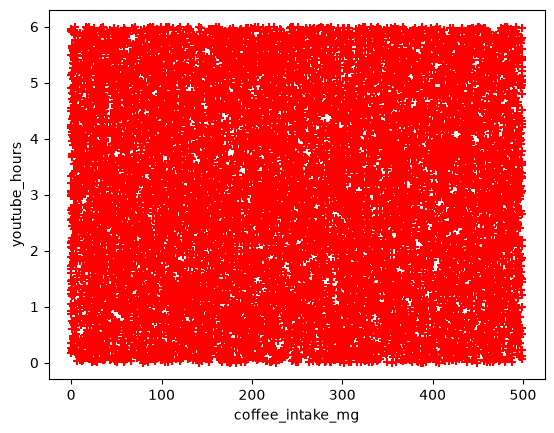

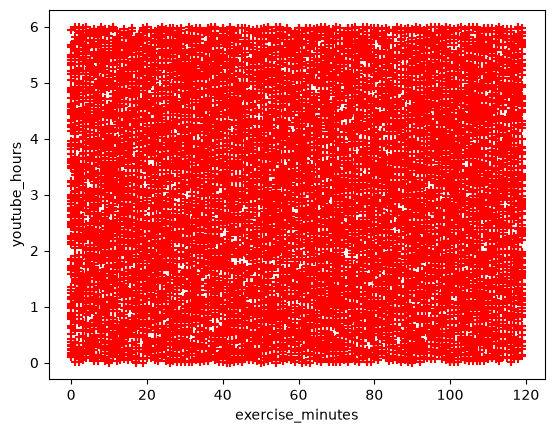

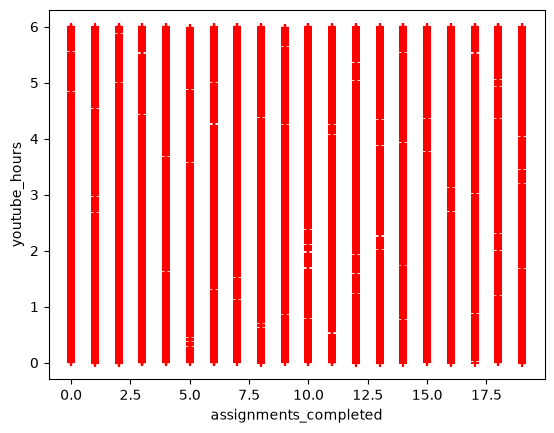

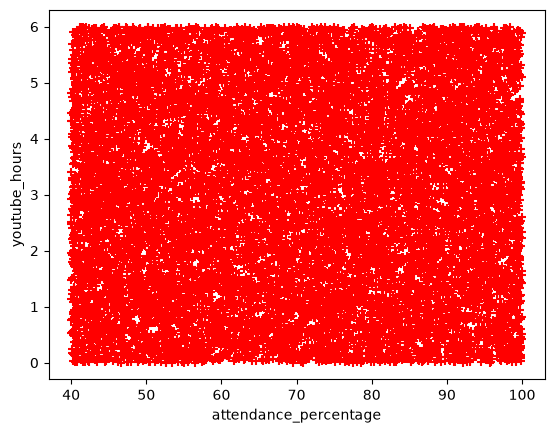

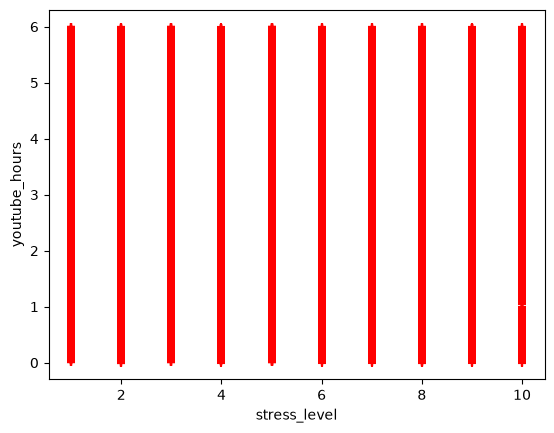

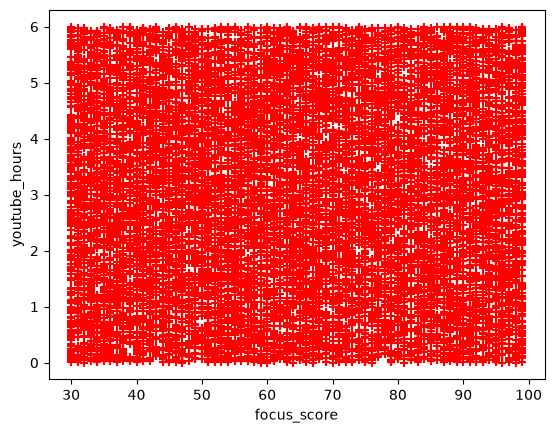

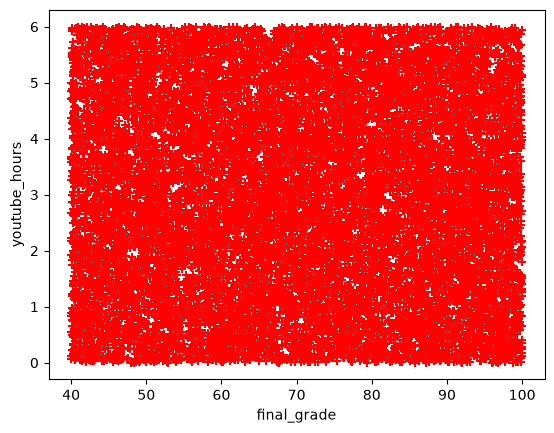

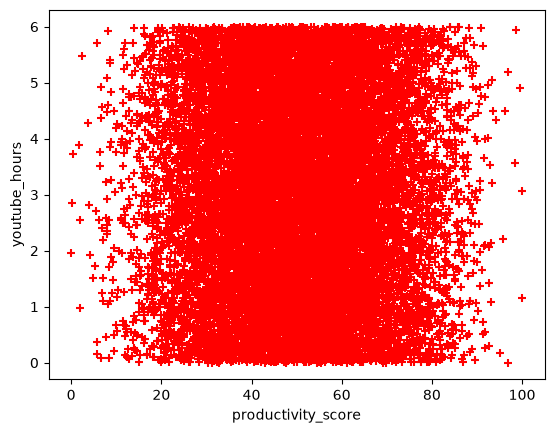

In [96]:
for i in df.columns:
    %matplotlib inline
    plt.xlabel(i)
    plt.ylabel("youtube_hours")
    plt.scatter(df[i]	, df.youtube_hours, marker = "+", color = 'red')
    plt.show()

## Testing gaming hours to see if it has a lienar relaitonshipw ith other features
No linear relationship with other feaures

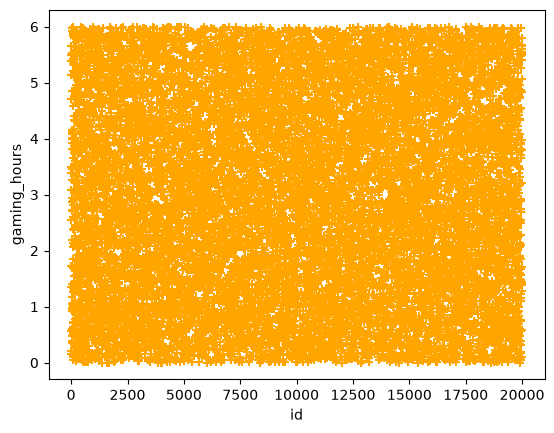

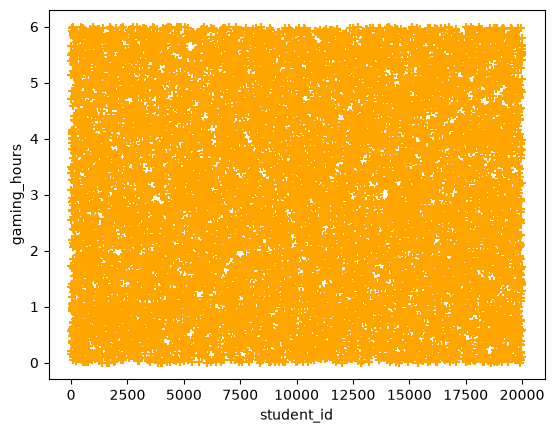

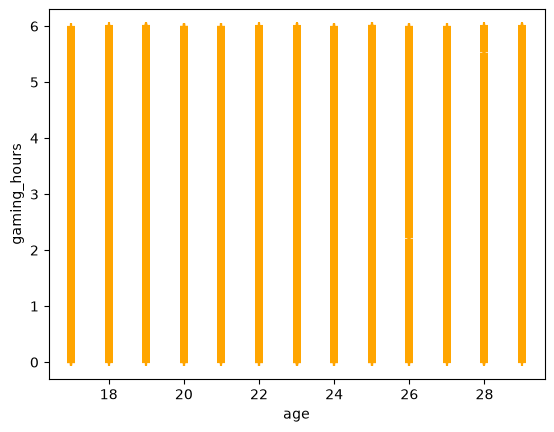

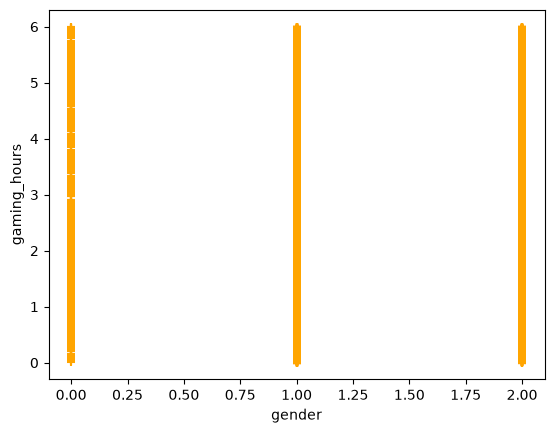

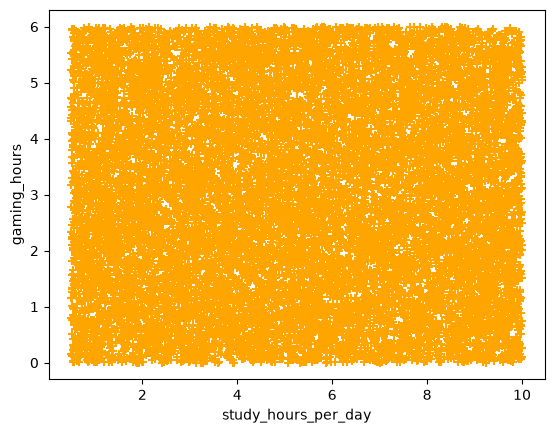

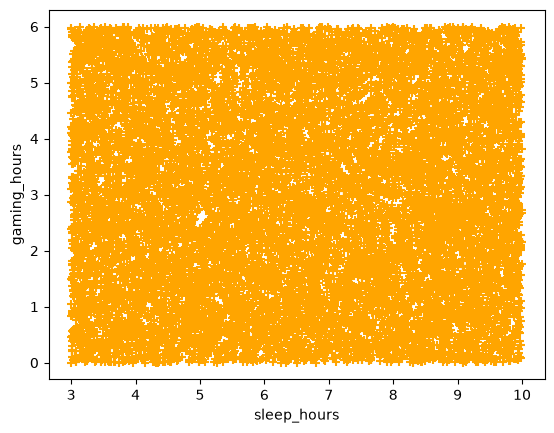

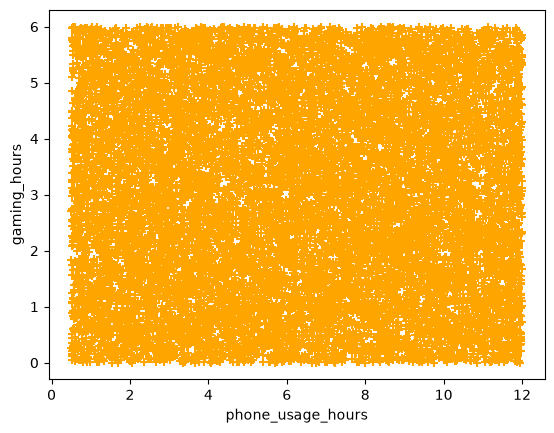

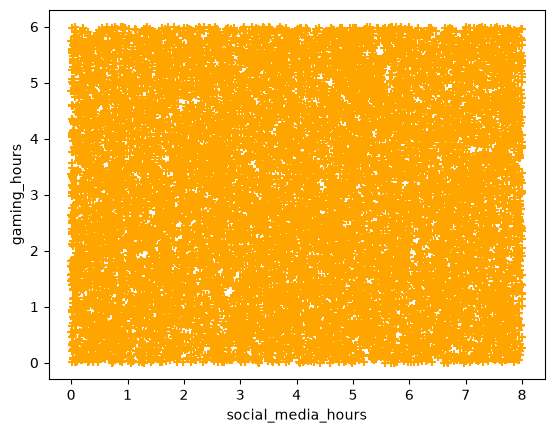

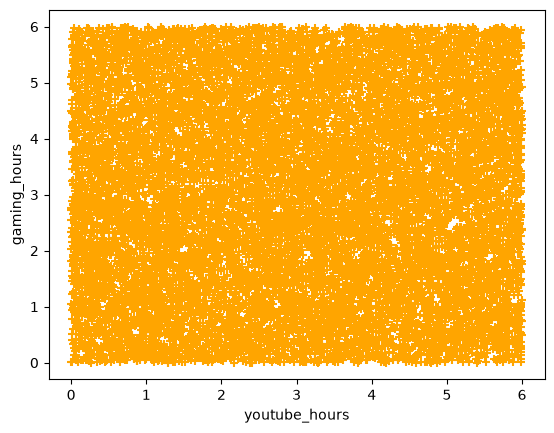

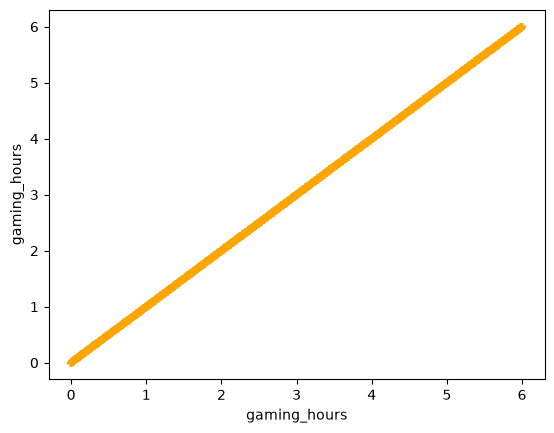

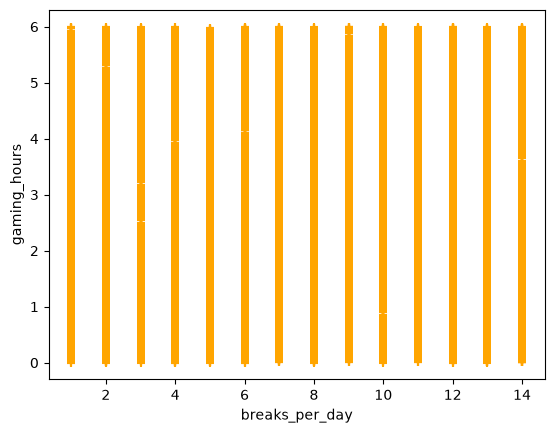

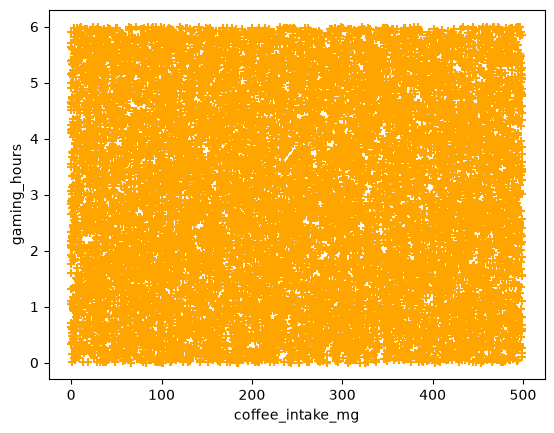

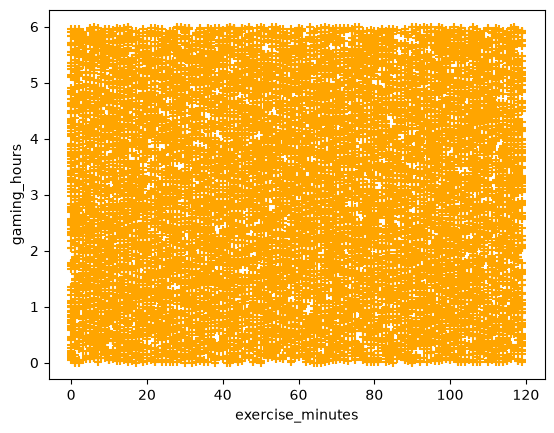

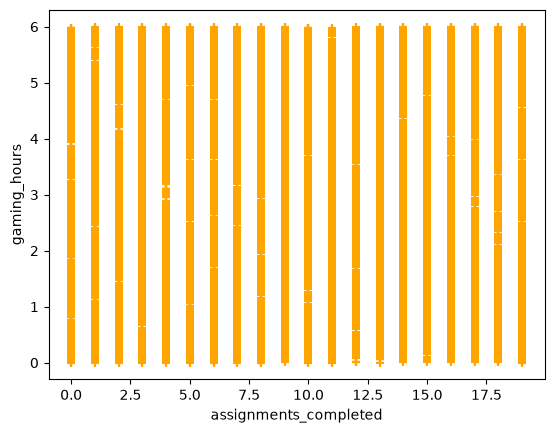

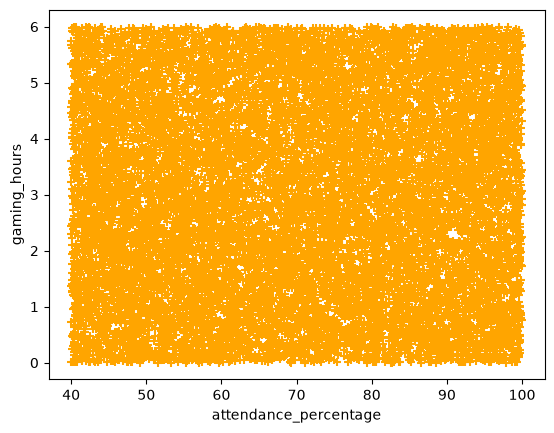

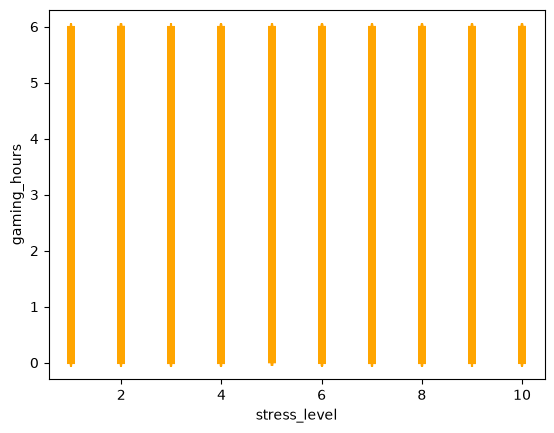

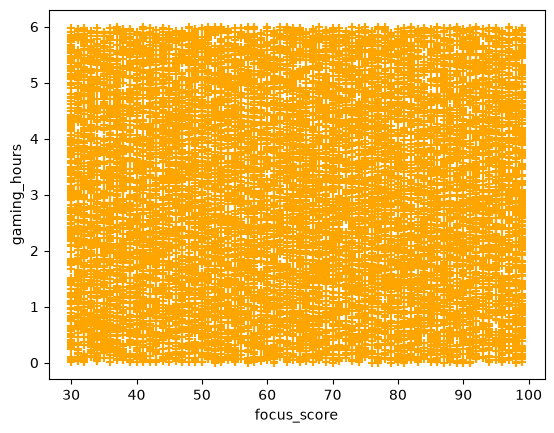

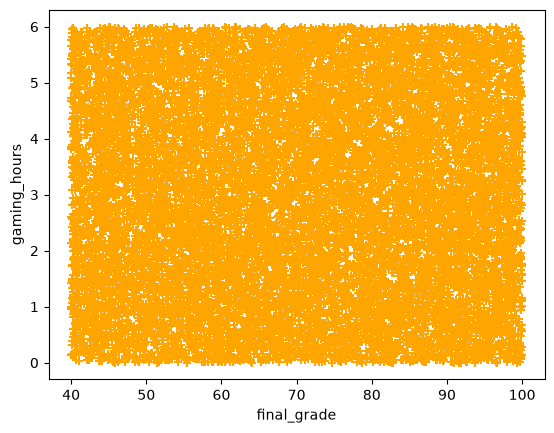

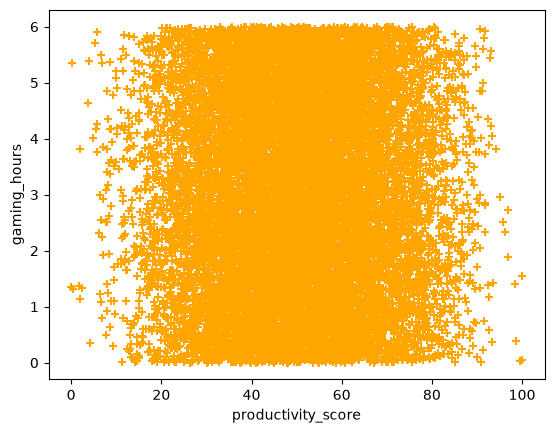

In [97]:
for i in df.columns:
    %matplotlib inline
    plt.xlabel(i)
    plt.ylabel("gaming_hours")
    plt.scatter(df[i]	, df.gaming_hours, marker = "+", color = 'orange')
    plt.show()

Notes: 
relationship score( H (High), L (Low), M (Medium))

Features that show a linear relationship
<br> gender - low acceleration
<br> study_hours_per_day - (High acceleration)
<br> sleep_hours - (Medium acceleration)
<br> phone_usage_hours - (Medium deceleration)
<br> attendance_precentage - (Low acceleration)
<br> focus Score - (medium accerlation)
<br> Stress Level - (low - deceleration)
little relation
<br> 
<br>
<br>
<br>

In [32]:
df_new = df.drop(columns = ['id', 'age', 'student_id','social_media_hours','youtube_hours', 'gaming_hours','breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'final_grade'])

In [34]:
df_new.head()

,gender,study_hours_per_day,sleep_hours,phone_usage_hours,attendance_percentage,stress_level,focus_score,productivity_score
0,0,4.56,7.61,1.70,52.72,6,68,55.29
1,1,7.95,8.17,4.24,87.51,1,69,78.68
2,2,6.06,9.02,3.17,72.39,8,57,60.66
3,1,1.40,8.06,2.35,87.47,5,34,37.51
4,2,9.27,7.39,10.68,47.66,5,37,50.72


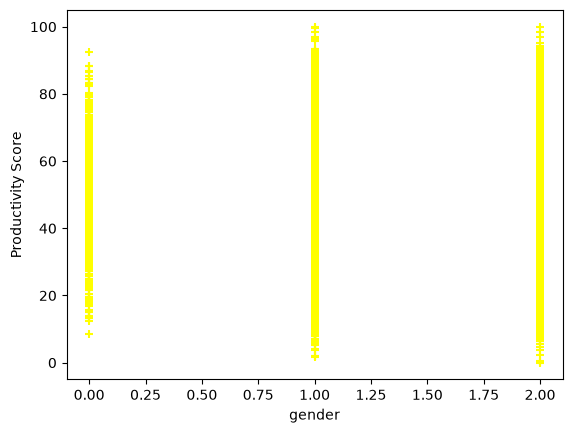

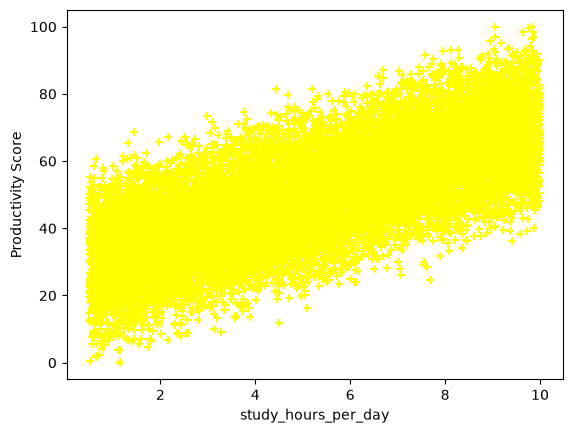

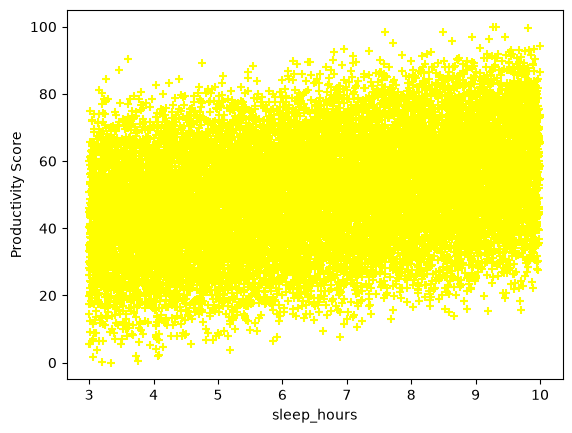

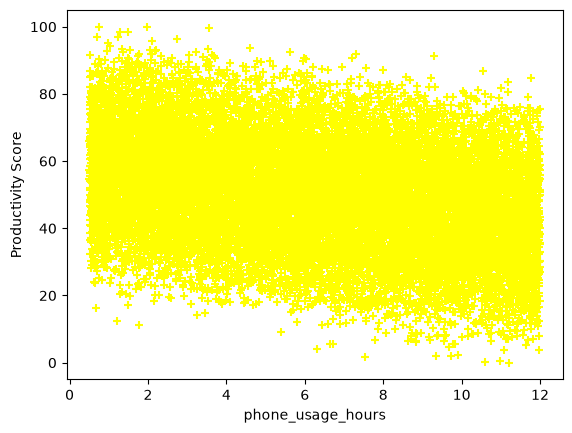

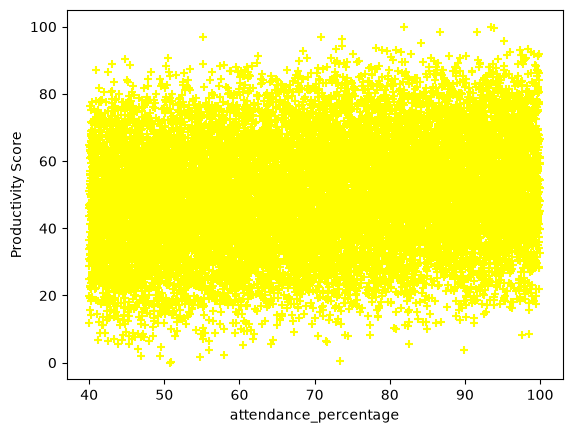

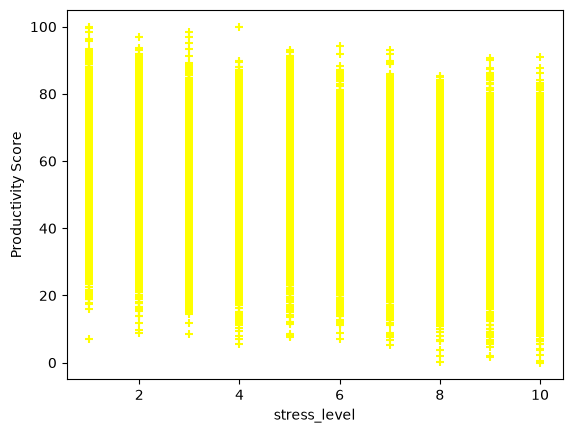

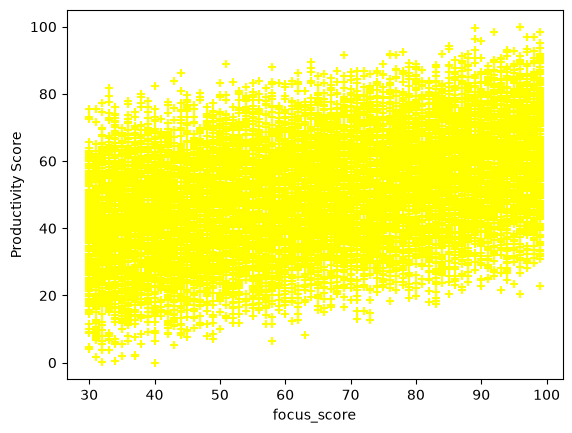

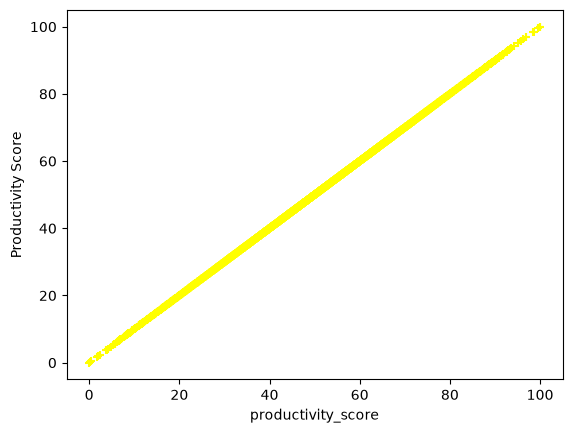

In [37]:
for i in df_new.columns:
    %matplotlib inline
    plt.xlabel(i)
    plt.ylabel("Productivity Score")
    plt.scatter(df[i]	, df.productivity_score, marker = "+", color = 'yellow')
    plt.show()

In [ ]:
#Testing 

## Data cleaning

In [50]:
# Checking duplicates
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
15995    False
15996    False
15997    False
15998    False
15999    False
Length: 16000, dtype: bool

In [64]:
#checking outliers using zscore
from scipy import stats
count =0
z_score = np.abs(stats.zscore(df_new["study_hours_per_day"]))
for z in z_score:
    if z > 3:
        count +=1
print(count)

0


In [65]:
count =0
for i in df_new:
    z_score = np.abs(stats.zscore(df_new[i]))
    for z in z_score:
        if z > 3:
            count +=1
    print(i, " = ", count)

gender  =  0
study_hours_per_day  =  0
sleep_hours  =  0
phone_usage_hours  =  0
attendance_percentage  =  0
stress_level  =  0
focus_score  =  0
productivity_score  =  9


In [85]:
X = df_new.drop(columns = ['productivity_score'])
y = df_new['productivity_score']

X

,gender,study_hours_per_day,sleep_hours,phone_usage_hours,attendance_percentage,stress_level,focus_score
0,0,4.56,7.61,1.70,52.72,6,68
1,1,7.95,8.17,4.24,87.51,1,69
2,2,6.06,9.02,3.17,72.39,8,57
3,1,1.40,8.06,2.35,87.47,5,34
4,2,9.27,7.39,10.68,47.66,5,37
...,...,...,...,...,...,...,...
15995,1,1.04,4.86,6.58,62.40,1,80
15996,2,4.85,8.61,4.66,40.52,10,43
15997,0,7.97,8.72,11.30,75.09,5,71
15998,1,2.64,8.64,1.47,73.99,6,31


In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 42)


In [87]:
X_train

,gender,study_hours_per_day,sleep_hours,phone_usage_hours,attendance_percentage,stress_level,focus_score
4397,2,7.47,6.36,0.87,60.13,1,30
15548,2,1.64,6.24,11.89,43.39,4,56
8449,2,7.43,3.21,0.65,83.16,6,56
4963,2,2.79,5.06,3.17,89.10,5,81
13111,1,3.82,4.43,9.90,94.67,8,69
...,...,...,...,...,...,...,...
13418,2,7.23,8.30,7.21,75.09,8,92
5390,2,1.34,4.59,11.80,83.78,4,34
860,1,3.58,4.71,1.28,84.91,5,40
15795,1,2.33,3.01,2.48,62.80,7,83


In [88]:
y_train

4397     60.12
15548    19.26
8449     58.55
4963     49.57
13111    35.20
         ...  
13418    68.99
5390     13.08
860      41.15
15795    37.41
7270     41.88
Name: productivity_score, Length: 14400, dtype: float64

In [89]:
model = LinearRegression()
model.fit(X_train, y_train)
model.predict(X_test)

array([30.74568249, 37.32128906, 27.75556638, ..., 30.33834412,
       55.40353041, 60.16397971], shape=(1600,))

In [90]:
r2_score = model.score(X_test, y_test)
r2_score

0.9999999674023498

### Full features = R2_score = 0.9999999673993064
## Selected feaures = R2_score = 0.9999999674023498

## Saved training data to file

In [91]:
import joblib
joblib.dump(model, "student_productivity_prediction.pkl")

['student_productivity_prediction.pkl']

Automation

In [99]:


# Target
target = "productivity_score"

# Get numerical columns
numeric_features = df.select_dtypes(include="number").columns

# Remove target from features
numeric_features = numeric_features.drop(target)

# Calculate correlation with productivity
correlations = df[numeric_features].corrwith(df[target])

# Sort by absolute correlation
correlations = correlations.abs().sort_values(ascending=False)

print(correlations)

study_hours_per_day      0.732300
focus_score              0.415125
sleep_hours              0.338570
phone_usage_hours        0.326874
stress_level             0.195620
attendance_percentage    0.174750
coffee_intake_mg         0.019559
id                       0.010767
student_id               0.010767
breaks_per_day           0.007023
assignments_completed    0.004874
age                      0.004461
gender                   0.004042
youtube_hours            0.001988
exercise_minutes         0.001533
gaming_hours             0.000801
final_grade              0.000342
social_media_hours       0.000131
dtype: float64


Automation

In [100]:
#cehcking diffrent combinations with the r2 score
from itertools import combinations

features = [
    "study_hours_per_day",
    "focus_score",
    "sleep_hours",
    "phone_usage_hours",
    "stress_level",
    "attendance_percentage"
]

results = []

for r in range(1, len(features) + 1):
    for combination in combinations(features, r):

        X = df[list(combination)]
        y = df["productivity_score"]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            random_state=42
        )

        model = LinearRegression()
        model.fit(X_train, y_train)

        score = model.score(X_test, y_test)

        results.append((combination, score))

results.sort(key=lambda x: x[1], reverse=True)

for combination, score in results:
    print(combination, score)

('study_hours_per_day', 'focus_score', 'sleep_hours', 'phone_usage_hours', 'stress_level', 'attendance_percentage') 0.9999999686213229
('study_hours_per_day', 'focus_score', 'sleep_hours', 'phone_usage_hours', 'stress_level') 0.9696614353342604
('study_hours_per_day', 'focus_score', 'sleep_hours', 'phone_usage_hours', 'attendance_percentage') 0.9639717679774493
('study_hours_per_day', 'focus_score', 'sleep_hours', 'phone_usage_hours') 0.9325585560644282
('study_hours_per_day', 'focus_score', 'sleep_hours', 'stress_level', 'attendance_percentage') 0.8943200086945093
('study_hours_per_day', 'focus_score', 'phone_usage_hours', 'stress_level', 'attendance_percentage') 0.8865250685745044
('study_hours_per_day', 'focus_score', 'sleep_hours', 'stress_level') 0.8613828652931956
('study_hours_per_day', 'focus_score', 'phone_usage_hours', 'stress_level') 0.8560235642867425
('study_hours_per_day', 'focus_score', 'sleep_hours', 'attendance_percentage') 0.855492311111689
('study_hours_per_day', 'fo

In [ ]:
#Retraining based on the highest r2score
